Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

import warnings
warnings.filterwarnings("ignore")


/Users/devanshujoshi/Documents/Devanshu/USA/Boston University/DS701/ds-muckrock-liberation/fa25-team-a/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# State file paths
# Financial Statements
financial_statements_1_path = 'data/Financial Statements/Financial Statements Format-1.csv'
financial_statements_2_europe_path = 'data/Financial Statements/Financial Statements Format-2 Europe.csv'
financial_statements_2_korea_path = 'data/Financial Statements/Financial Statements Format-2 Korea.csv'
financial_statements_2_japan_path = 'data/Financial Statements/Financial Statements Format-2 Japan.csv'
financial_statements_3_europe_path = 'data/Financial Statements/Financial Statements Format-3 Europe.csv'
financial_statements_3_korea_path = 'data/Financial Statements/Financial Statements Format-3 Korea.csv'
financial_statements_3_japan_path = 'data/Financial Statements/Financial Statements Format-3 Japan.csv'
financial_statements_4_path = 'data/Financial Statements/Financial Statements Format-4.csv'

# Navy Revenue
navy_revenue_1_path = 'data/Navy Revenue/Navy Revenue Report FY16-FY24-1 Format 1.csv'
navy_revenue_2_path = 'data/Navy Revenue/Navy Revenue Report FY20-FY24-1 Format 2.csv'

# Marine Revenue
marine_revenue_1_path = 'data/Marine Revenue/Marine Revenue FY20-FY24 Format 1.csv'
marine_revenue_2_path = 'data/Marine Revenue/Marine Revenue FY20-FY24 Format 2.csv'

# Base Location
bases_file_path = 'data/bases.json'

In [3]:
# Import and read csv files
# Financial Statements
fs1 = pd.read_csv(financial_statements_1_path)
fs2e = pd.read_csv(financial_statements_2_europe_path)
fs2k = pd.read_csv(financial_statements_2_korea_path)
fs2j = pd.read_csv(financial_statements_2_japan_path)
fs3e = pd.read_csv(financial_statements_3_europe_path)
fs3k = pd.read_csv(financial_statements_3_korea_path)
fs3j = pd.read_csv(financial_statements_3_japan_path)
fs4 = pd.read_csv(financial_statements_4_path)

# Navy Revenue
nr1 = pd.read_csv(navy_revenue_1_path)
nr2 = pd.read_csv(navy_revenue_2_path)

# Marine Revenue
mr1 = pd.read_csv(marine_revenue_1_path)
mr2 = pd.read_csv(marine_revenue_2_path)

# Bases Locations
bases = pd.read_json(bases_file_path)

In [4]:
# List of desired unique values
desired_values = [
    'Cash--Operating', 'Cash--Restricted', 'Accounts Receivable',
    'Prepaid Expenses', 'Fixed Assets', 'Less Accum Depreciation',
    'TOTAL ASSETS',
    'Accounts Payable', 'Distributions Payable', 'Accrued Liabilities',
    'Accrued Salaries', 'Accrued Leave Payable', 'Total Liabilities',
    'EQUITY', 'TOTAL LIABILITIES & EQUITY'
]

# Function to normalize each entry
def normalize_value(val):
    if pd.isna(val):
        return val
    val = val.strip()  # Remove leading/trailing spaces
    val = ' '.join(val.split())  # Replace multiple spaces with single
    val = val.replace('.', '')  # Remove any dots
    # Match closest desired value
    for d in desired_values:
        if val.lower() == d.lower():
            return d
    return val  # If no match, keep as is

# Apply normalization to the 'Details' column
fs1['Details'] = fs1['Details'].apply(normalize_value)

# Check unique values now
print(fs1['Details'].unique())


['Cash--Operating' 'Cash--Restricted' 'Accounts Receivable'
 'Prepaid Expenses' 'Fixed Assets' 'Less Accum Depreciation'
 'TOTAL ASSETS' 'Accounts Payable' 'Distributions Payable'
 'Accrued Liabilities' 'Accrued Salaries' 'Accrued Leave Payable'
 'Total Liabilities' 'EQUITY' 'TOTAL LIABILITIES & EQUITY' 'Cash'
 'Less Accum Pepreciation' 'LIABILITIES' 'Total Liabilities EQUITY']


In [5]:
def formate_value(val):
    if pd.isna(val):
        return val
    val = val.strip()
    val = val.replace('"', '')
    val = val.replace(',', '')
    val = val.replace("-", '')            
    val = val.replace(" ", '')
    val = val.replace("·", '')
    val = float(val)
    return val

def to_string(val):
    if pd.isna(val):
        return val
    val = str(val)
    return val

# Convert Numeric Values
fs4["March Europe"] = fs4["March Europe"].apply(formate_value)
fs4["March Korea"] = fs4["March Korea"].apply(formate_value)
fs4["March Japan"] = fs4["March Japan"].apply(formate_value)
fs4["YTD\nEurope"] = fs4["YTD\nEurope"].apply(formate_value)
fs4["YTD\nKorea"] = fs4["YTD\nKorea"].apply(formate_value)
fs4["YTD\nJapan"] = fs4["YTD\nJapan"].apply(formate_value)

# Convert to date and time
fs4["Year"] = fs4["Year"].apply(to_string)
fs4["MonthYearString"] = fs4["Month"] + ' ' + fs4["Year"]
fs4['Last_Day_Date'] = pd.to_datetime(fs4['MonthYearString'], format="%B %Y") + pd.tseries.offsets.MonthEnd(0)


In [6]:
# Define the top 10 bases
TOP_10_BASES = [
    'Camp Humphreys',
    'Okinawa Marines', 
    'Yokosuka Navy',
    'AFRC Dragon Hill Lodge',
    'Daegu',
    'Kaiserslautern',
    'Wiesbaden',
    'Casey & Hovey',
    'Sasebo Navy',
    'Stuttgart'
]

In [7]:
def clean_base_name(name):
    """Clean and standardize base names by removing extra spaces and standardizing formatting"""
    if pd.isna(name):
        return name
    
    # Remove extra spaces (multiple spaces, tabs, etc.)
    name = re.sub(r'\s+', ' ', str(name).strip())
    
    # Standardize common base name variations
    name = re.sub(r'Camp\s+', 'Camp ', name)
    name = re.sub(r'AFRC\s+', 'AFRC ', name)
    name = re.sub(r'Navy\s*$', 'Navy', name)
    name = re.sub(r'Marines\s*$', 'Marines', name)
    
    # Specific known variations - ensure they match our TOP_10_BASES
    name = name.replace('Casey &   Hovey', 'Casey & Hovey')
    name = name.replace('Casey & Hovey', 'Casey & Hovey')
    name = name.replace('Camp     Humphreys', 'Camp Humphreys')
    name = name.replace('AFRC   Dragon   Hill   Lodge', 'AFRC Dragon Hill Lodge')
    name = name.replace('AFRC  Dragon  Hill  Lodge', 'AFRC Dragon Hill Lodge')
    name = name.replace('Sanna Navy', 'Sanno Navy')  # Fix typo
    name = name.replace('Wiesb3den', 'Wiesbaden')  # Fix typo
    name = name.replace('Ansb3ch', 'Ansbach')  # Fix typo
    
    # Ensure base names match our predefined list
    for base in TOP_10_BASES:
        if base.lower() in name.lower():
            return base
    
    return name.strip()

def clean_currency_value(value):
    """Clean and convert currency string to float"""
    if pd.isna(value) or value == '' or value == 0.00:
        return 0.0
    
    # Handle negative values and various formats
    if isinstance(value, str):
        # Remove commas and spaces
        value = value.replace(',', '').replace(' ', '')
        # Handle negative values with parentheses or minus sign
        if '(' in value and ')' in value:
            value = '-' + value.replace('(', '').replace(')', '')
        # Handle trailing minus sign
        if value.endswith('-'):
            value = '-' + value[:-1]
        # Remove any non-numeric characters except decimal point and minus
        value = re.sub(r'[^\d.-]', '', value)
        
        if value == '' or value == '-':
            return 0.0
    
    try:
        return float(value)
    except (ValueError, TypeError):
        return 0.0

def categorize_branch(location):
    """Categorize locations by military branch"""
    location_lower = str(location).lower()
    
    if 'navy' in location_lower:
        return 'Navy'
    elif 'marines' in location_lower:
        return 'Marines'
    elif any(word in location_lower for word in ['army', 'ansbach', 'baumholder', 'grafenwoehr', 'hohenfels', 'wiesbaden']):
        return 'Army'
    elif 'air' in location_lower or 'afrc' in location_lower:
        return 'Air Force'
    else:
        return 'Total'

def categorize_region(location):
    """Categorize locations by geographic region"""
    location_lower = str(location).lower()
    
    if any(word in location_lower for word in ['germany', 'europe', 'kaiserslautern', 'grafenwoehr', 
                                            'wiesbaden', 'vicenza', 'livorno', 'stuttgart', 
                                            'baumholder', 'ansbach', 'schinnen', 'hohenfels',
                                            'naples', 'sigonella', 'rota', 'souda', 'brunssum']):
        return 'Europe'
    elif any(word in location_lower for word in ['korea', 'seoul', 'casey', 'hovey', 'uijongbu', 
                                                'humphreys', 'daegu', 'chinhae', 'mujuk']):
        return 'Korea'
    elif any(word in location_lower for word in ['japan', 'zama', 'fuji', 'sanno', 'atsugi', 
                                                'okinawa', 'iwakuni', 'sasebo', 'yokosuka']):
        return 'Japan'
    elif 'singapore' in location_lower:
        return 'Singapore'
    else:
        return 'Other'

def load_and_clean_data(file_path):
    """Load and clean the financial data"""
    df = pd.read_csv(file_path)
    
    # Clean column names
    df.columns = [col.replace('\n', ' ').strip() for col in df.columns]
    
    # Clean base names first
    df['Locations'] = df['Locations'].apply(clean_base_name)
    
    # Clean monetary columns
    monetary_columns = ['March Europe', 'March Korea', 'March Japan', 
                        'YTD Europe', 'YTD Korea', 'YTD Japan']
    
    for col in monetary_columns:
        df[col] = df[col].apply(clean_currency_value)
    
    # Filter out total rows for base-level analysis
    df = df[~df['Locations'].str.contains('Total', na=False)]
    df = df[~df['Locations'].str.contains('Europe', na=False)]  # Remove summary rows
    
    # Filter to only include our predefined top 10 bases
    df = df[df['Locations'].isin(TOP_10_BASES)]
    
    # Add branch and region categories
    df['Branch'] = df['Locations'].apply(categorize_branch)
    df['Region'] = df['Locations'].apply(categorize_region)
    
    # Create a proper datetime column
    df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))
    
    return df

def create_monthly_revenue_column(df):
    """Create a monthly revenue column by summing across regions"""
    df['Monthly_Revenue'] = df[['March Europe', 'March Korea', 'March Japan']].sum(axis=1)
    df['YTD_Revenue'] = df[['YTD Europe', 'YTD Korea', 'YTD Japan']].sum(axis=1)
    return df

In [8]:
# Load and clean data
print("Loading and cleaning data...")
df = load_and_clean_data('data/Financial Statements/Financial Statements Format-4.csv')
df = create_monthly_revenue_column(df)


Loading and cleaning data...


In [9]:
df

,Locations,March Europe,March Korea,March Japan,YTD Europe,YTD Korea,YTD Japan,Month,Year,Branch,Region,Date,Monthly_Revenue,YTD_Revenue
0,Kaiserslautern,435381.00,0.00,0.00,1769195.35,0.00,0.00,March,2023,Total,Europe,2023-03-01,435381.00,1769195.35
2,Wiesbaden,265851.45,0.00,0.00,1376947.40,0.00,0.00,March,2023,Army,Europe,2023-03-01,265851.45,1376947.40
5,Stuttgart,200290.70,0.00,0.00,1211060.55,0.00,0.00,March,2023,Total,Europe,2023-03-01,200290.70,1211060.55
15,AFRC Dragon Hill Lodge,0.00,244860.65,0.00,0.00,2402628.65,0.00,March,2023,Air Force,Other,2023-03-01,244860.65,2402628.65
17,Casey & Hovey,0.00,188646.35,0.00,0.00,1031024.40,0.00,March,2023,Total,Korea,2023-03-01,188646.35,1031024.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,Camp Humphreys,0.00,917606.55,0.00,0.00,3062426.05,0.00,December,2023,Total,Korea,2023-12-01,917606.55,3062426.05
1620,Daegu,0.00,150007.59,0.00,0.00,318959.30,0.00,December,2023,Total,Korea,2023-12-01,150007.59,318959.30
1627,Okinawa Marines,0.00,0.00,792074.90,0.00,0.00,2994713.95,December,2023,Marines,Japan,2023-12-01,792074.90,2994713.95
1630,Sasebo Navy,0.00,0.00,111517.10,0.00,0.00,651567.15,December,2023,Navy,Japan,2023-12-01,111517.10,651567.15


In [10]:
df["ds"] = df["Date"]
df['unique_id'] = df["Locations"]
df['y'] = df["Monthly_Revenue"]

In [11]:
df

,Locations,March Europe,March Korea,March Japan,YTD Europe,YTD Korea,YTD Japan,Month,Year,Branch,Region,Date,Monthly_Revenue,YTD_Revenue,ds,unique_id,y
0,Kaiserslautern,435381.00,0.00,0.00,1769195.35,0.00,0.00,March,2023,Total,Europe,2023-03-01,435381.00,1769195.35,2023-03-01,Kaiserslautern,435381.00
2,Wiesbaden,265851.45,0.00,0.00,1376947.40,0.00,0.00,March,2023,Army,Europe,2023-03-01,265851.45,1376947.40,2023-03-01,Wiesbaden,265851.45
5,Stuttgart,200290.70,0.00,0.00,1211060.55,0.00,0.00,March,2023,Total,Europe,2023-03-01,200290.70,1211060.55,2023-03-01,Stuttgart,200290.70
15,AFRC Dragon Hill Lodge,0.00,244860.65,0.00,0.00,2402628.65,0.00,March,2023,Air Force,Other,2023-03-01,244860.65,2402628.65,2023-03-01,AFRC Dragon Hill Lodge,244860.65
17,Casey & Hovey,0.00,188646.35,0.00,0.00,1031024.40,0.00,March,2023,Total,Korea,2023-03-01,188646.35,1031024.40,2023-03-01,Casey & Hovey,188646.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,Camp Humphreys,0.00,917606.55,0.00,0.00,3062426.05,0.00,December,2023,Total,Korea,2023-12-01,917606.55,3062426.05,2023-12-01,Camp Humphreys,917606.55
1620,Daegu,0.00,150007.59,0.00,0.00,318959.30,0.00,December,2023,Total,Korea,2023-12-01,150007.59,318959.30,2023-12-01,Daegu,150007.59
1627,Okinawa Marines,0.00,0.00,792074.90,0.00,0.00,2994713.95,December,2023,Marines,Japan,2023-12-01,792074.90,2994713.95,2023-12-01,Okinawa Marines,792074.90
1630,Sasebo Navy,0.00,0.00,111517.10,0.00,0.00,651567.15,December,2023,Navy,Japan,2023-12-01,111517.10,651567.15,2023-12-01,Sasebo Navy,111517.10


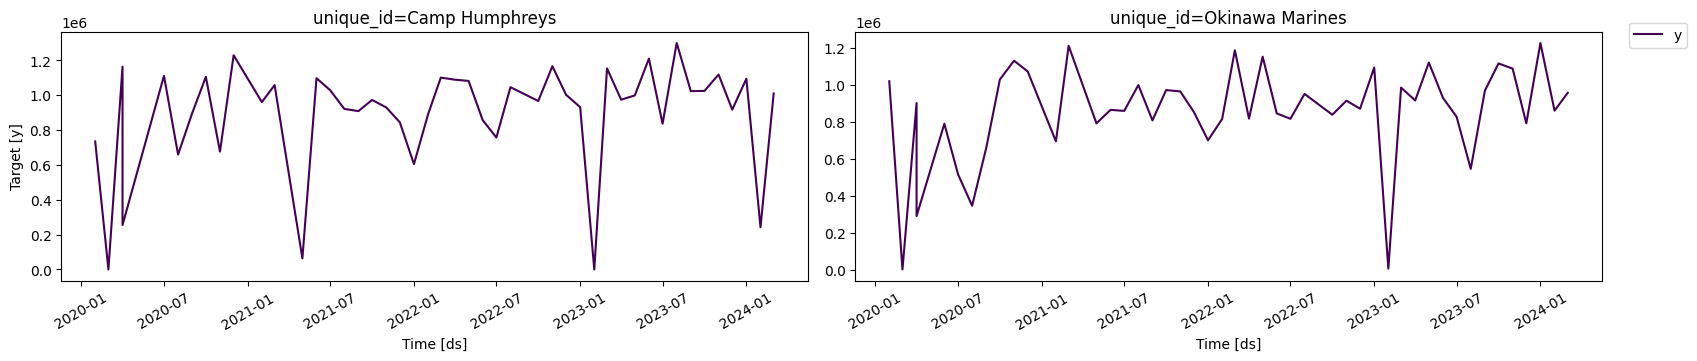

In [12]:
plot_series(df=df, ids=["Camp Humphreys", "Okinawa Marines"], palette="viridis")

In [13]:
horizon = 7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=df)
preds = sf.predict(h=horizon)

ValueError: could not convert string to float: 'Kaiserslautern'

In [ ]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [ ]:
df[df['y'].apply(lambda x: isinstance(x, str))]


,Locations,March Europe,March Korea,March Japan,YTD Europe,YTD Korea,YTD Japan,Month,Year,Branch,Region,Date,Monthly_Revenue,YTD_Revenue,ds,unique_id,y
